In [49]:
import pandas as pd

df = pd.read_csv('outputs/framing_gpt_results.csv')

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11973 entries, 0 to 11972
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   hit_id                 11973 non-null  str  
 1   row_id                 11973 non-null  int64
 2   source                 11973 non-null  str  
 3   Title                  11973 non-null  str  
 4   hit_text               11973 non-null  str  
 5   context_idx            11973 non-null  int64
 6   count_hits             11973 non-null  int64
 7   count_unique_entities  11973 non-null  int64
 8   context_window         11973 non-null  str  
 9   model                  11973 non-null  str  
 10  response_id            11973 non-null  str  
 11  category               11973 non-null  str  
 12  evidence               3192 non-null   str  
 13  raw_response_json      11973 non-null  str  
dtypes: int64(4), str(10)
memory usage: 1.3 MB


In [50]:
df = df[['hit_id', 'row_id', 'source', 'Title', 'context_idx', 'context_window', 'category', 'evidence']]

In [ ]:
df

,hit_id,row_id,source,Title,context_idx,context_window,category,evidence
0,d844fe7dbcb4b28a,1,Antispiegel,Bereitet der Westen die Entmachtung oder sogar...,1,"Er hat es geschafft, seine Leute überall zu pl...",NEUTRAL,NaN
1,f785774b2205e418,4,Antispiegel,Fordert Russland wirklich die Vernichtung alle...,1,Viele haben Reitschuster aus der Corona-Zeit j...,DISINFORMATION/FALSCHDARSTELLUNG,Propagandisten von Bild-Zeitung
2,8beba1b1263837c4,5,Antispiegel,Der Spiegel macht mal wieder Berichterstattung...,1,Der Spiegel macht mal wieder Berichterstattung...,VERSAGEN/INKOMPETENZ,Berichterstattung für den Kindergarten
3,db28e215f2d3989d,5,Antispiegel,Der Spiegel macht mal wieder Berichterstattung...,2,Das NABU ist das vielleicht wichtigste Instrum...,NEUTRAL,NaN
4,387a8dd7ac2cedde,5,Antispiegel,Der Spiegel macht mal wieder Berichterstattung...,3,"Ich denke, die Antwort liegt auf der Hand. Mär...",POSITIONS-/PARTEILICHKEITS-BIAS,anti-russischen und pro-ukrainischen Propagand...
...,...,...,...,...,...,...,...,...
11968,d5264d5629b3ae25,20436,Tagesschau,Bis zu 100 Sternschnuppen pro Stunde sind möglich,1,Rechtzeitig zum neuen Jahr zeigt sich der Ster...,NEUTRAL,NaN
11969,a7bfcc1d5a5e0499,20437,Tagesschau,"Der letzte ""Supermond"" des Jahres",1,Und so hoch wie in diesem Jahr wird er wohl la...,NEUTRAL,NaN
11970,a3d2ff36023a08a5,20437,Tagesschau,"Der letzte ""Supermond"" des Jahres",2,Dezember 2026. SWR Kultur | SWR Impuls | 04.12...,NEUTRAL,NaN
11971,0049441f9d007ab9,20439,Tagesschau,Projekt zur Tierbeobachtung startet wieder,1,"Es war ein paar Mal schon so, dass es wirklich...",NEUTRAL,NaN


### Filter to mentions that include evidence (non-neutral)

In [51]:
df_evidence = df[df['evidence'].notna()]


In [65]:
df_evidence['source'].value_counts()

source
Tichys_Einblick      1254
Nius                  857
RT_de                 398
Antispiegel           309
Compact               182
Deutschlandkurier     138
Tagesschau             54
Name: count, dtype: int64

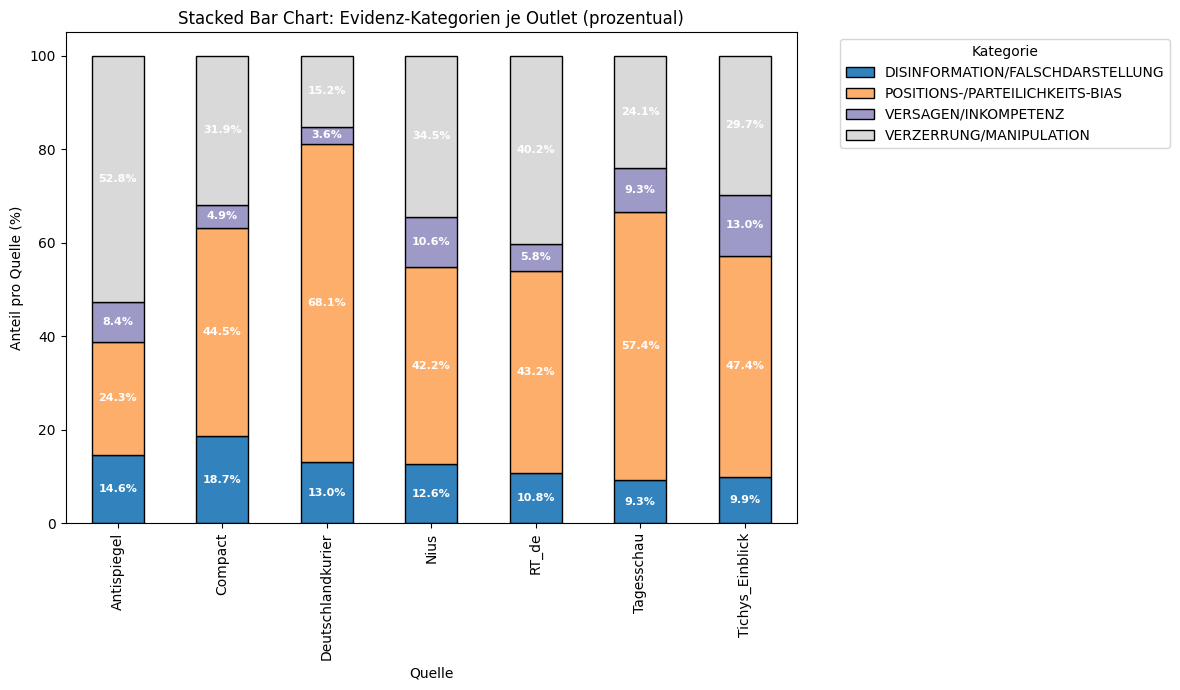

In [55]:
import matplotlib.pyplot as plt

# Group by source and category, count mentions
cat_counts = df_evidence.groupby(['source', 'category']).size().unstack(fill_value=0)

# Remove NEUTRAL and IRRELEVANT if you want only accusations (as below)
cat_counts = cat_counts.drop(columns=[c for c in ['NEUTRAL', 'IRRELEVANT'] if c in cat_counts.columns], errors='ignore')

# Convert to percent per source
cat_counts_pct = (cat_counts.T / cat_counts.sum(axis=1)).T * 100

# Plot as stacked bar chart
fig, ax = plt.subplots(figsize=(12, 7))
cat_counts_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab20c', edgecolor='black')

# Add percentage labels on the bars
for idx, row in enumerate(cat_counts_pct.values):
    y_offset = 0
    for col_i, val in enumerate(row):
        if val > 2:  # Only show label if segment is not too small
            ax.text(
                idx, 
                y_offset + val/2, 
                f"{val:.1f}%", 
                ha='center', va='center', fontsize=8, color='white', fontweight='bold'
            )
        y_offset += val

ax.set_ylabel('Anteil pro Quelle (%)')
ax.set_xlabel('Quelle')
ax.set_title('Stacked Bar Chart: Evidenz-Kategorien je Outlet (prozentual)')
ax.legend(title='Kategorie', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### TF-IDF on evidence phrases (one document per outlet)

Non-empty `evidence` strings are concatenated **per `source`**. Only rows with accusation/bias categories are kept (`NEUTRAL` and `IRRELEVANT` excluded). **Sublinear TF** reduces the advantage of very long outlet texts. Terms with **low IDF** recur across many outlets (shared accusation vocabulary); **high TF-IDF in one outlet** highlights terms concentrated there (distinctive versus the rest).


In [52]:
from IPython.display import display

import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# --- Build one pseudo-document per outlet (accusation-related evidence only) ---
work = df_evidence.copy()
work["evidence"] = work["evidence"].astype(str).str.strip()
work = work[work["evidence"] != ""]
work = work[~work["category"].isin(["NEUTRAL", "IRRELEVANT"])].copy()

docs_series = work.groupby("source", sort=True)["evidence"].agg(lambda parts: " ".join(parts))
sources = list(docs_series.index)
documents = [docs_series[s] for s in sources]

# German function words + short noise tokens (TF-IDF focuses on content-bearing terms)
GERMAN_STOP = {
    "der", "die", "das", "und", "oder", "ein", "eine", "einer", "einem", "einen",
    "ist", "sind", "war", "waren", "wird", "werden", "wurde", "wurden", "hat", "haben",
    "im", "in", "am", "an", "auf", "zu", "zum", "zur", "von", "vom", "mit", "nach",
    "als", "auch", "nicht", "nur", "wie", "so", "sich", "dass", "daß", "es", "er", "sie",
    "ihr", "ihre", "ihnen", "man", "bei", "aus", "über", "unter", "vor", "durch",
    "für", "gegen", "ohne", "um", "bis", "ob", "weil", "wenn", "noch", "schon",
    "mehr", "mich", "mir", "uns", "ihm", "ihn", "dem", "den", "des", "diese", "dieser",
    "dieses", "alle", "allem", "allen", "alles", "was", "wer", "wo", "wird", "sein",
    "seine", "seinem", "seinen", "seiner", "habe", "hast", "können", "kann",
    "müssen", "muß", "muss", "soll", "sollen", "wollen", "würde", "wäre", "hier", "dort",
    "ja", "nein", "all", "the", "pr",
    "ihren", "ihrer", "ihrem", "diesem", "diesen", "dessen", "deren",
}

vectorizer = TfidfVectorizer(
    lowercase=True,
    token_pattern=r"(?u)\b[\wäöüÄÖÜß]+\b",
    min_df=1,
    max_df=1.0,
    stop_words=list(GERMAN_STOP),
    sublinear_tf=True,
)
X = vectorizer.fit_transform(documents)
terms = np.array(vectorizer.get_feature_names_out())
idf = vectorizer.idf_

# --- Shared vocabulary: lowest IDF (appear in many / all outlet-documents) ---
n_shared = min(40, len(terms))
shared_order = np.argsort(idf)[:n_shared]
tfidf_shared = pd.DataFrame(
    {
        "term": terms[shared_order],
        "idf": idf[shared_order],
        "n_outlets_with_term": np.asarray(X[:, shared_order].getnnz(axis=0)).ravel(),
    }
)
display(tfidf_shared)

# --- Distinctive terms: highest TF-IDF per outlet ---
TOP_K = 25
rows = []
for i, src in enumerate(sources):
    col = X.getrow(i).toarray().ravel()
    order = np.argsort(-col)[:TOP_K]
    for rank, j in enumerate(order, start=1):
        if col[j] <= 0:
            continue
        rows.append(
            {
                "source": src,
                "rank": rank,
                "term": terms[j],
                "tfidf": col[j],
            }
        )

tfidf_by_outlet = pd.DataFrame(rows)
with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", None,
    "display.max_colwidth", None,
):
    display(tfidf_by_outlet)


,term,idf,n_outlets_with_term
0,medien,1.000000,7
1,news,1.000000,7
2,keine,1.000000,7
3,fake,1.000000,7
4,propaganda,1.133531,6
5,örr,1.133531,6
6,lügen,1.133531,6
7,staatsmedien,1.133531,6
8,taz,1.133531,6
9,erfunden,1.133531,6


,source,rank,term,tfidf
0,Antispiegel,1,leser,0.131134
1,Antispiegel,2,artikel,0.104928
2,Antispiegel,3,spiegel,0.095984
3,Antispiegel,4,gewollte,0.094345
4,Antispiegel,5,vergessen,0.094345
5,Antispiegel,6,selensky,0.094345
6,Antispiegel,7,lesern,0.091621
7,Antispiegel,8,verschweigt,0.086825
8,Antispiegel,9,darstellt,0.082971
9,Antispiegel,10,erfahren,0.082639


### Evidence phrase embeddings + clustering

**Sentence model (same as BERTopic in this repo):** `paraphrase-multilingual-MiniLM-L12-v2` from [`bertopic_config.py`](../1a_BERTopic/bertopic_config.py) — multilingual MiniLM, strong German sentence similarity and used across your topic-modeling notebooks.

Non-empty `evidence` strings are embedded; vectors are **L2-normalized** and **K-means** is run with `n_clusters` in **8–12** (default **10**). Adjust `N_CLUSTERS` below if needed.


In [56]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sentence_transformers import SentenceTransformer

# Same default as thesis BERTopic pipeline (German + other languages)
EMBEDDING_MODEL = "paraphrase-multilingual-MiniLM-L12-v2"
N_CLUSTERS = 6 

evid_work = df_evidence.copy()
evid_work["evidence"] = evid_work["evidence"].astype(str).str.strip()
evid_work = evid_work[evid_work["evidence"] != ""].reset_index(drop=True)
texts = evid_work["evidence"].tolist()
print(f"Embedding {len(texts):,} evidence phrases with {EMBEDDING_MODEL!r} …")

model = SentenceTransformer(EMBEDDING_MODEL)
embeddings = model.encode(
    texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=False,
)

X = normalize(embeddings, norm="l2", axis=1)
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

evid_work["evidence_cluster"] = labels
df_evidence_clustered = evid_work  # use in later cells

sizes = (
    evid_work.groupby("evidence_cluster", sort=True)
    .size()
    .rename("n_phrases")
    .reset_index()
)
display(sizes)

# Representative phrases per cluster: highest cosine similarity to cluster centroid
centroids = kmeans.cluster_centers_
rows = []
for k in range(N_CLUSTERS):
    mask = labels == k
    idx = np.flatnonzero(mask)
    c = centroids[k]
    c = c / np.linalg.norm(c)
    sims = X[mask] @ c
    top_local = np.argsort(-sims)[:12]
    for rank, il in enumerate(top_local, start=1):
        gi = idx[il]
        rows.append(
            {
                "evidence_cluster": k,
                "rank_in_cluster": rank,
                "similarity_to_centroid": float(sims[il]),
                "evidence": texts[gi],
                "source": evid_work["source"].iloc[gi],
            }
        )

cluster_anchors = pd.DataFrame(rows)
with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", None, "display.max_colwidth", 120):
    display(cluster_anchors)


Embedding 3,192 evidence phrases with 'paraphrase-multilingual-MiniLM-L12-v2' …


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4358.03it/s]
BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 50/50 [00:02<00:00, 17.01it/s]


,evidence_cluster,n_phrases
0,0,421
1,1,403
2,2,508
3,3,903
4,4,673
5,5,284


,evidence_cluster,rank_in_cluster,similarity_to_centroid,evidence,source
0,0,1,0.911061,nichtssagenden,Tichys_Einblick
1,0,2,0.894513,berichteten mit keiner Silbe,Compact
2,0,3,0.882562,nicht berücksichtigt,RT_de
3,0,4,0.877579,geflissentlich ignoriert,Tichys_Einblick
4,0,5,0.876373,recht unbeteiligt,Tichys_Einblick
5,0,6,0.876254,unkritisch,Antispiegel
6,0,7,0.866295,flissentlich übersehen,Tichys_Einblick
7,0,8,0.862918,nicht in den Sinn kommen,Tichys_Einblick
8,0,9,0.859675,blieb unerwähnt,Tichys_Einblick
9,0,10,0.855856,bleibt unausgesprochen,Tichys_Einblick


In [60]:
evid_work['evidence_cluster'].value_counts()

evidence_cluster
3    903
4    673
2    508
0    421
1    403
5    284
Name: count, dtype: int64

In [61]:

evid_work.to_csv("evidence_clusters_fullv2.csv", index=False)
print("Saved evidence_clusters_full.csv ")

Saved evidence_clusters_full.csv 


/Users/gretawette/Documents/Thesis/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


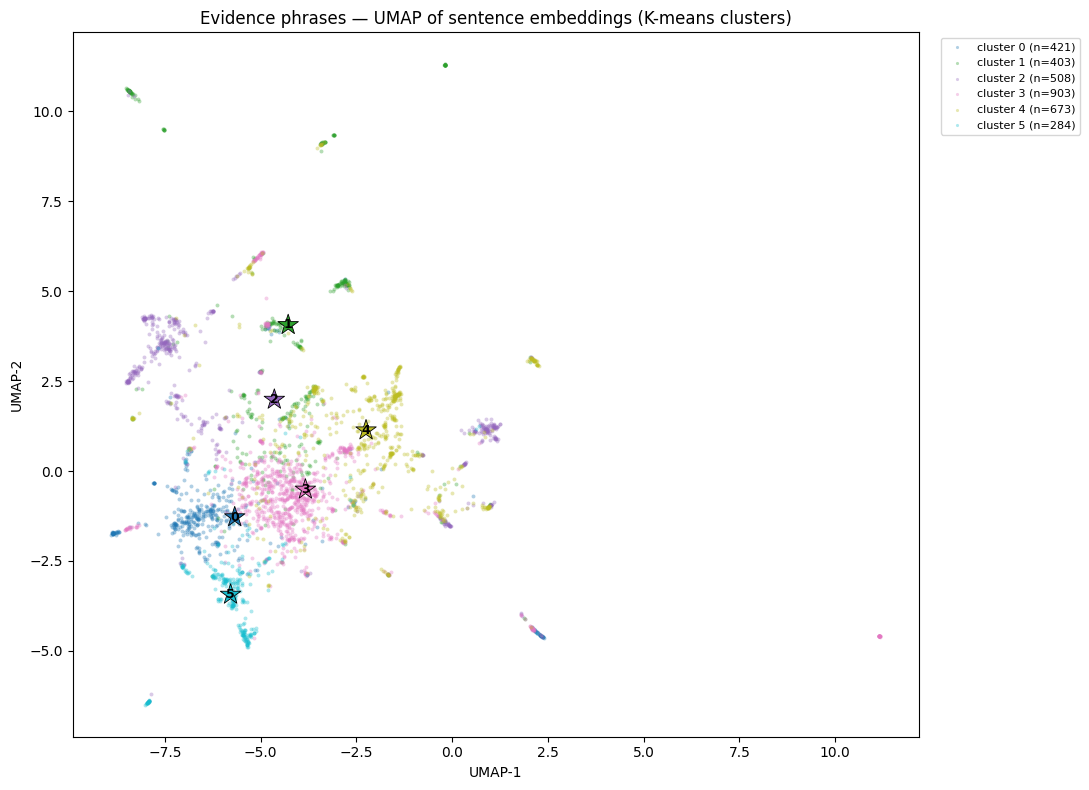

,evidence_cluster,rank_in_cluster,similarity_to_centroid,evidence,source
0,0,1,0.911061,nichtssagenden,Tichys_Einblick
1,0,2,0.894513,berichteten mit keiner Silbe,Compact
2,0,3,0.882562,nicht berücksichtigt,RT_de
3,0,4,0.877579,geflissentlich ignoriert,Tichys_Einblick
4,0,5,0.876373,recht unbeteiligt,Tichys_Einblick
5,0,6,0.876254,unkritisch,Antispiegel
6,0,7,0.866295,flissentlich übersehen,Tichys_Einblick
7,0,8,0.862918,nicht in den Sinn kommen,Tichys_Einblick
8,0,9,0.859675,blieb unerwähnt,Tichys_Einblick
9,0,10,0.855856,bleibt unausgesprochen,Tichys_Einblick


In [62]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import umap

# 2D map of normalized embeddings; colour = K-means cluster; stars = mean UMAP position per cluster
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.08,
    metric="cosine",
    random_state=42,
)
X_2d = reducer.fit_transform(X)

centroids_2d = np.vstack(
    [X_2d[labels == k].mean(axis=0) for k in range(N_CLUSTERS)]
)

base = mpl.colormaps["tab20" if N_CLUSTERS > 10 else "tab10"]
palette = [base(i / max(N_CLUSTERS - 1, 1)) for i in range(N_CLUSTERS)]

fig, ax = plt.subplots(figsize=(11, 8))
for k in range(N_CLUSTERS):
    m = labels == k
    ax.scatter(
        X_2d[m, 0],
        X_2d[m, 1],
        c=[palette[k]],
        s=8,
        alpha=0.35,
        linewidths=0,
        label=f"cluster {k} (n={m.sum():,})",
        rasterized=True,
    )
ax.scatter(
    centroids_2d[:, 0],
    centroids_2d[:, 1],
    c=palette,
    s=240,
    marker="*",
    edgecolors="black",
    linewidths=0.6,
    zorder=5,
)
for k in range(N_CLUSTERS):
    ax.annotate(
        str(k),
        (centroids_2d[k, 0], centroids_2d[k, 1]),
        fontsize=9,
        fontweight="bold",
        ha="center",
        va="center",
        color="black",
        zorder=6,
    )
ax.set_title("Evidence phrases — UMAP of sentence embeddings (K-means clusters)")
ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8,
    markerscale=0.8,
    frameon=True,
)
plt.tight_layout()
plt.show()

# cluster_anchors includes the outlet (source) for each anchor phrase
with pd.option_context(
    "display.max_rows", None,
    "display.max_columns", None,
    "display.width", None,
    "display.max_colwidth", 100,
):
    display(cluster_anchors.sort_values(["evidence_cluster", "rank_in_cluster"]))


In [43]:
# Save the cluster anchor table (including evidence_cluster and all assigned rows) as CSV

# Assumes `cluster_anchors` is a DataFrame containing all evidence phrases,
# with at least the columns ['evidence_cluster', ...].
# Save all rows, including the cluster assignments.

cluster_anchors.sort_values(["evidence_cluster", "rank_in_cluster"])\
    .to_csv("evidence_clusters_full.csv", index=False)
print("Saved evidence_clusters_full.csv with all 10 clusters and assigned rows.")

Saved evidence_clusters_full.csv with all 10 clusters and assigned rows.


### Outlet share per evidence cluster

100% stacked bars: within each cluster, the proportion of evidence phrases from each `source` (outlet).


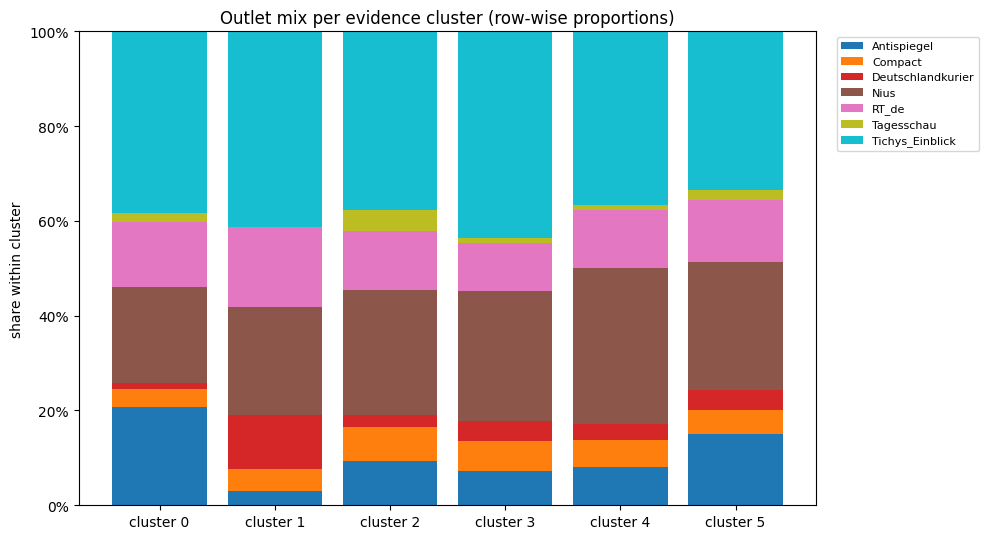

source,Antispiegel,Compact,Deutschlandkurier,Nius,RT_de,Tagesschau,Tichys_Einblick
evidence_cluster,,,,,,,
0,20.7%,3.8%,1.4%,20.2%,13.8%,1.9%,38.2%
1,3.0%,4.7%,11.4%,22.8%,16.9%,0.0%,41.2%
2,9.3%,7.3%,2.6%,26.4%,12.4%,4.5%,37.6%
3,7.2%,6.4%,4.2%,27.5%,10.0%,1.1%,43.6%
4,8.2%,5.6%,3.4%,32.8%,12.2%,1.0%,36.7%
5,15.1%,4.9%,4.2%,27.1%,13.0%,2.1%,33.5%


In [63]:
from IPython.display import display

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Requires `df_evidence_clustered` from the embedding cell (columns: evidence_cluster, source)
df = df_evidence_clustered.copy()
counts = (
    df.groupby(["evidence_cluster", "source"], observed=False)
    .size()
    .rename("n")
    .reset_index()
)
pivot = counts.pivot_table(
    index="evidence_cluster",
    columns="source",
    values="n",
    aggfunc="sum",
    fill_value=0,
)
pivot = pivot.sort_index()
outlets = sorted(pivot.columns)
pivot = pivot[outlets]
shares = pivot.div(pivot.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

n_out = len(outlets)
base = mpl.colormaps["tab20" if n_out > 10 else "tab10"]
colors = [base(i / max(n_out - 1, 1)) for i in range(n_out)]

fig, ax = plt.subplots(figsize=(max(10, 0.9 * len(pivot.index)), 5.5))
x = np.arange(len(pivot.index))
bottom = np.zeros(len(pivot))
for i, outlet in enumerate(outlets):
    vals = shares[outlet].to_numpy()
    ax.bar(x, vals, bottom=bottom, label=outlet, color=colors[i], width=0.82)
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels([f"cluster {k}" for k in pivot.index])
ax.set_ylabel("share within cluster")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
ax.set_title("Outlet mix per evidence cluster (row-wise proportions)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

display(shares.map(lambda v: f"{v:.1%}"))


## depict category per category

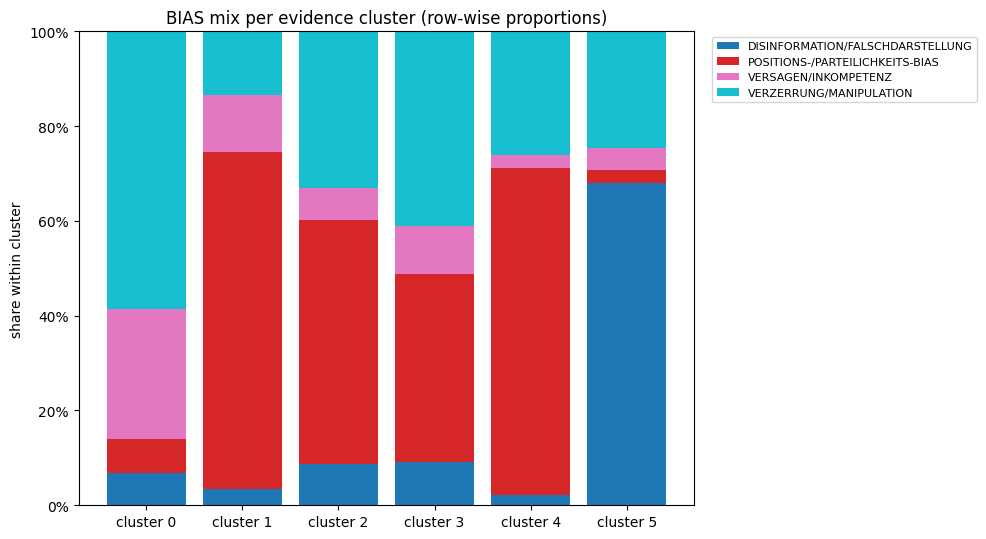

category,DISINFORMATION/FALSCHDARSTELLUNG,POSITIONS-/PARTEILICHKEITS-BIAS,VERSAGEN/INKOMPETENZ,VERZERRUNG/MANIPULATION
evidence_cluster,,,,
0,6.9%,7.1%,27.3%,58.7%
1,3.5%,71.0%,12.2%,13.4%
2,8.7%,51.6%,6.7%,33.1%
3,9.2%,39.6%,10.2%,41.0%
4,2.1%,69.1%,2.8%,26.0%
5,68.0%,2.8%,4.6%,24.6%


In [68]:
# Compute bar chart of categories (BIAS) stacked per evidence_cluster

# Calculate counts of BIAS per evidence_cluster
bias_counts = (
    df.groupby(["evidence_cluster", "category"], observed=False)
    .size()
    .rename("n")
    .reset_index()
)
bias_pivot = bias_counts.pivot_table(
    index="evidence_cluster",
    columns="category",
    values="n",
    aggfunc="sum",
    fill_value=0,
)
bias_pivot = bias_pivot.sort_index()
categories = sorted(bias_pivot.columns)
bias_pivot = bias_pivot[categories]
bias_shares = bias_pivot.div(bias_pivot.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

n_cat = len(categories)
base_cat = mpl.colormaps["tab20" if n_cat > 10 else "tab10"]
cat_colors = [base_cat(i / max(n_cat - 1, 1)) for i in range(n_cat)]

fig, ax = plt.subplots(figsize=(max(10, 0.9 * len(bias_pivot.index)), 5.5))
x = np.arange(len(bias_pivot.index))
bottom = np.zeros(len(bias_pivot))
for i, cat in enumerate(categories):
    vals = bias_shares[cat].to_numpy()
    ax.bar(x, vals, bottom=bottom, label=cat, color=cat_colors[i], width=0.82)
    bottom += vals

ax.set_xticks(x)
ax.set_xticklabels([f"cluster {k}" for k in bias_pivot.index])
ax.set_ylabel("share within cluster")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1.0))
ax.set_title("BIAS mix per evidence cluster (row-wise proportions)")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

display(bias_shares.map(lambda v: f"{v:.1%}"))